In [1]:
import numpy as np
import os
import matplotlib.pyplot as plt
import mat73
import pickle
import pandas as pd
import pingouin as pg
import xarray as xr
from globals import behavDir
from util import hedges_g

import pandas as pd
from lfp import make_freq_masks
import globals as gl

import seaborn as sb
import PcmPy as pcm
from scipy.stats import norm
plt.style.use('default')

Base directory found: /cifs/diedrichsen/data/SensoriMotorPrediction/
Base directory: /cifs/diedrichsen/data/SensoriMotorPrediction/


In [2]:
### colours ###
cmap_plan = plt.get_cmap('Greys')
col_plan = [cmap_plan(i) for i in np.linspace(.3, .9, 5)]

cmap_index = plt.get_cmap('Greens')
col_index = [cmap_index(i) for i in np.linspace(.3, .9, 5)][:4]

cmap_ring = plt.get_cmap('Oranges')
col_ring = [cmap_ring(i) for i in np.linspace(.3, .9, 5)][1:]

colour_mapping = {
    '100-0%': col_plan[0],
    '75-25%': col_plan[1],
    '50-50%': col_plan[2],
    '25-75%': col_plan[3],
    '0-100%': col_plan[4],
    '100-0%,ext': col_index[0],
    '75-25%,ext': col_index[1],
    '50-50%,ext': col_index[2],
    '25-75%,ext': col_index[3],
    '75-25%,flx': col_ring[0],
    '50-50%,flx': col_ring[1],
    '25-75%,flx': col_ring[2],
    '0-100%,flx': col_ring[3],
}

###############

In [42]:
baseDir = '/cifs/pruszynski/Marco/SensoriMotorPrediction'
lfpDir = 'LFPs' #+ monkey + '/'
spkDir = 'spikes' #+ monkey + '/'
pcmDir = 'pcm'
behavDir = 'Behavioural'
recDir = 'Recordings'
cfg = mat73.loadmat(os.path.join(baseDir, lfpDir,'Malfoy/cfg.PMd-19.mat'))['cfg']
foi = cfg['foi']
freq_masks = make_freq_masks(cfg)

freqs = ['delta', 'theta', 'alpha-beta', 'gamma']
recordings = {
            'Malfoy': {
                'PFC': [17, 19, 20, 21, 22, 23, 24],
                'PMd': [10, 13, 14, 15, 16, 17, 19, 20, 21, 22, 23, 24],
                'M1': [12, 13, 25, 27, 28],
                'S1': [ 5, 9, 11, 15, 16, 26, 27, 28]
            },
            'Pert': {
                'PMd': [4, 6, 7, 10, 20],
                'M1': [2, 3, 14, 20],
                'S1': [15],
                'PFC': [8, 9, 10, 11, 12],
            }
        }

cuePre = 0
cueIdx = 20
cuePost = 84
pertPre = cuePost
pertIdx = pertPre + 30
pertPost = pertPre + 70

t_cue = np.linspace(0, cuePost - 1, cuePost)
t_pert = np.linspace(pertPre, pertPost - 1, pertPost - pertPre) + 5
t = np.concatenate((t_cue, t_pert))

monkey = ['Malfoy', 'Pert']

rois = ['PFC', 'PMd', 'M1', 'S1']
freq = freq_masks['alpha-beta']

var_expl = {"lfp": [], "spk": [], 'roi': []}  # each becomes list over rois
lfp = {'lpf': []}
kin = {"elbow": [], "prob": [], 'cond': [], 'rec': [], 'roi': []}
corr = {"lfp": [], "spk": [], 'roi': []}
epoch = 'exec'
for roi in rois:
    for mon in monkey:
        for rec in recordings[mon][roi]:
            theta_lfp_comp = np.load(os.path.join(baseDir, pcmDir, mon, f'theta_in.lfp.component.{roi}.{epoch}-{rec}.npy'))
            theta_spk_comp = np.load(os.path.join(baseDir, pcmDir, mon, f'theta_in.spk.component.{roi}.{epoch}-{rec}.npy'))
            var_tot_lfp = np.load(os.path.join(baseDir, pcmDir, mon, f'var_tot.lfp.{roi}.{epoch}-{rec}.npy'))
            var_tot_spk = np.load(os.path.join(baseDir, pcmDir, mon, f'var_tot.spk.{roi}.{epoch}-{rec}.npy'))
            var_expl["lfp"].append(np.exp(theta_lfp_comp[...,:-1]) / var_tot_lfp.T[..., None])
            var_expl["spk"].append(np.exp(theta_spk_comp[:, :-1]) / var_tot_spk.T[..., None])
            var_expl["roi"].append(roi)

var_expl_lfp_plan = xr.DataArray(data=np.stack(var_expl["lfp"]),
                   dims=('roi', 'freq', 'time', 'model'),
                   coords={
                       'roi': var_expl['roi'],
                       'freq': foi,
                       'time': t,
                       'model': ['sensory input', 'expectation', 'surprise']})
var_expl_spk_plan = xr.DataArray(data=np.stack(var_expl["spk"]),
                   dims=('roi', 'time', 'model'),
                   coords={
                       'roi': var_expl['roi'],
                       'time': t,
                       'model': ['sensory input','expectation', 'surprise']})

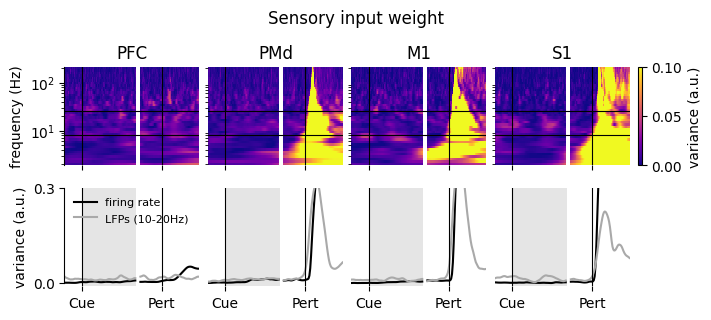

In [43]:
fig, axs_ = plt.subplots(2, len(rois)+1, sharex='col', figsize=(7, 3), gridspec_kw={"width_ratios": [80] * len(rois) + [2]}, constrained_layout=True)

axs = axs_[:, :-1]
ax_c = axs_[:, -1]

freq1, freq2 = 8, 25

vmin, vmax = 0, .1
color = [['darkred', 'navy'], ['lightcoral', 'lightblue']]
model = 'sensory input'
for r, roi in enumerate(rois):
    lfp_tf1 = var_expl_lfp_plan.sel(roi=roi, time=slice(0, cuePost-1), model=model).mean(dim='roi').values
    lfp_tf2 = var_expl_lfp_plan.sel(roi=roi, time=slice(pertPre, None), model=model).mean(dim='roi').values
    lfp_t1 = var_expl_lfp_plan.sel(roi=roi, time=slice(0, cuePost-1), model=model, freq=slice(freq1, freq2)).mean(dim=('roi', 'freq')).values
    lfp_t2 = var_expl_lfp_plan.sel(roi=roi, time=slice(pertPre, None), model=model, freq=slice(freq1, freq2)).mean(dim=('roi', 'freq')).values
    h = axs[0, r].pcolormesh(t_cue, foi, lfp_tf1, vmin=vmin, vmax=vmax, cmap='plasma')
    axs[0, r].pcolormesh(t_pert, foi, lfp_tf2, vmin=vmin, vmax=vmax, cmap='plasma')
    axs[0, r].set_yscale('log')
    axs[0, r].set_title(roi)
    axs[0, r].axhline(freq1, color='k', lw='.8')
    axs[0, r].axhline(freq2, color='k', lw='.8')
    axs[0, r].set_ylabel('frequency (Hz)') if r==0 else None
    firing1 = var_expl_spk_plan.sel(roi=roi,time=slice(0, cuePost-1), model=model).mean(dim='roi').values
    firing2 = var_expl_spk_plan.sel(roi=roi, time=slice(pertPre, None), model=model).mean(dim='roi').values
    axs[1, r].plot(t_cue, firing1, color='k', label='firing rate')
    axs[1, r].plot(t_pert, firing2, color='k')
    axs[1, r].plot(t_cue, lfp_t1, color='darkgrey', label='LFPs (10-20Hz)')
    axs[1, r].plot(t_pert, lfp_t2, color='darkgrey')
    axs[1, r].axvspan(cueIdx, cuePost, color='grey', alpha=.2, lw=0)
    axs[1, r].set_ylim([-.01, .3])
    axs[1, r].set_yticks((0, .3))
    axs[1, r].spines['left'].set_bounds(0, .3)
    axs[1, r].set_ylabel('variance (a.u.)') if r==0 else None
    for i in range(2):
        axs[i, r].axvline(cueIdx, color='k', lw='.8')
        axs[i, r].axvline(pertIdx, color='k', lw='.8')
        axs[i, r].set_xticks([cueIdx, pertIdx])
        axs[i, r].set_xticklabels(['Cue', 'Pert'])
        axs[i, r].set_yticks([]) if r>0 else None
        axs[i, r].spines[['bottom', 'right', 'top']].set_visible(False) if r==0 else axs[i, r].spines[['bottom', 'right', 'top', 'left']].set_visible(False)

axs[1, 0].legend(frameon=False, ncol=1, fontsize=8, loc='upper left')

fig.colorbar(h, cax=ax_c[0], label='variance (a.u.)')
for ax in ax_c[1:]:
    ax.remove()

fig.suptitle(f'Sensory input weight', va='center')

plt.show()

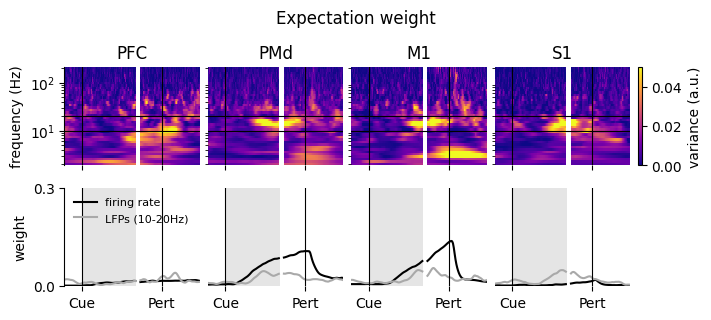

In [44]:
fig, axs_ = plt.subplots(2, len(rois) + 1, sharex='col', figsize=(7, 3), gridspec_kw={"width_ratios": [80] * len(rois) + [2]}, constrained_layout=True)

axs = axs_[:, :-1]
ax_c = axs_[:, -1]

vmin, vmax = 0, .05
color = [['darkred', 'navy'], ['lightcoral', 'lightblue']]
model = 'expectation'
for r, roi in enumerate(rois):
    lfp_tf1 = var_expl_lfp_plan.sel(roi=roi, time=slice(0, cuePost-1), model=model).mean(dim='roi').values
    lfp_tf2 = var_expl_lfp_plan.sel(roi=roi, time=slice(pertPre, None), model=model).mean(dim='roi').values
    lfp_t1 = var_expl_lfp_plan.sel(roi=roi, time=slice(0, cuePost-1), model=model, freq=slice(10, 20)).mean(dim=('roi', 'freq')).values
    lfp_t1_tmp = var_expl_lfp_plan.sel(roi=roi, time=slice(0, cuePost-1), model=model, freq=slice(10, 20)).mean(dim=( 'freq')).values
    lfp_t2 = var_expl_lfp_plan.sel(roi=roi, time=slice(pertPre, None), model=model, freq=slice(10, 20)).mean(dim=('roi', 'freq')).values
    h = axs[0, r].pcolormesh(t_cue, foi, lfp_tf1, vmin=vmin, vmax=vmax, cmap='plasma')
    axs[0, r].pcolormesh(t_pert, foi, lfp_tf2, vmin=vmin, vmax=vmax, cmap='plasma')
    axs[0, r].set_yscale('log')
    axs[0, r].set_title(roi)
    axs[0, r].axhline(10, color='k', lw='.8')
    axs[0, r].axhline(20, color='k', lw='.8')
    axs[0, r].set_ylabel('frequency (Hz)') if r==0 else None
    firing1 = var_expl_spk_plan.sel(roi=roi,time=slice(0, cuePost-1), model=model).mean(dim='roi').values
    firing2 = var_expl_spk_plan.sel(roi=roi, time=slice(pertPre, None), model=model).mean(dim='roi').values
    axs[1, r].plot(t_cue, firing1, color='k', label='firing rate')
    axs[1, r].plot(t_pert, firing2, color='k')
    axs[1, r].plot(t_cue, lfp_t1, color='darkgrey', label='LFPs (10-20Hz)')
    axs[1, r].plot(t_pert, lfp_t2, color='darkgrey')
    #axs[1, r].plot(t_cue, lfp_t1_tmp.T, color='darkgrey')
    axs[1, r].axvspan(cueIdx, cuePost, color='grey', alpha=.2, lw=0)
    # axs[1, r].set_ylim([-.01, .05])
    axs[1, r].set_yticks((0, .3))
    axs[1, r].spines['left'].set_bounds(0, .3)
    axs[1, r].set_ylabel('weight') if r==0 else None
    for i in range(2):
        axs[i, r].axvline(cueIdx, color='k', lw='.8')
        axs[i, r].axvline(pertIdx, color='k', lw='.8')
        axs[i, r].set_xticks([cueIdx, pertIdx])
        axs[i, r].set_xticklabels(['Cue', 'Pert'])
        axs[i, r].set_yticks([]) if r>0 else None
        axs[i, r].spines[['bottom', 'right', 'top']].set_visible(False) if r==0 else axs[i, r].spines[['bottom', 'right', 'top', 'left']].set_visible(False)

axs[1, 0].legend(frameon=False, ncol=1, fontsize=8, loc='upper left')

fig.colorbar(h, cax=ax_c[0], label='variance (a.u.)')
for ax in ax_c[1:]:
    ax.remove()

fig.suptitle(f'Expectation weight', va='center')

plt.show()

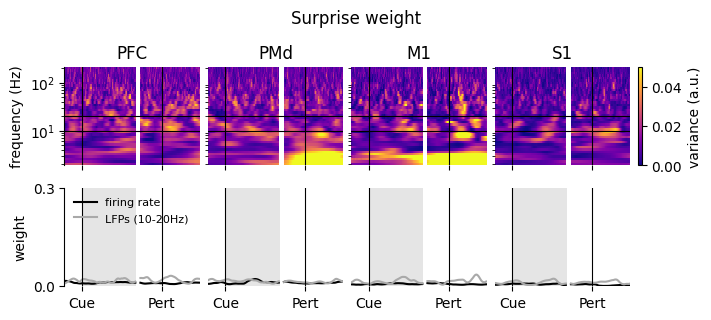

In [45]:
fig, axs_ = plt.subplots(2, len(rois) + 1, sharex='col', figsize=(7, 3), gridspec_kw={"width_ratios": [80] * len(rois) + [2]}, constrained_layout=True)

axs = axs_[:, :-1]
ax_c = axs_[:, -1]

vmin, vmax = 0, .05
color = [['darkred', 'navy'], ['lightcoral', 'lightblue']]
model = 'surprise'
for r, roi in enumerate(rois):
    lfp_tf1 = var_expl_lfp_plan.sel(roi=roi, time=slice(0, cuePost-1), model=model).mean(dim='roi').values
    lfp_tf2 = var_expl_lfp_plan.sel(roi=roi, time=slice(pertPre, None), model=model).mean(dim='roi').values
    lfp_t1 = var_expl_lfp_plan.sel(roi=roi, time=slice(0, cuePost-1), model=model, freq=slice(10, 20)).mean(dim=('roi', 'freq')).values
    lfp_t1_tmp = var_expl_lfp_plan.sel(roi=roi, time=slice(0, cuePost-1), model=model, freq=slice(10, 20)).mean(dim=( 'freq')).values
    lfp_t2 = var_expl_lfp_plan.sel(roi=roi, time=slice(pertPre, None), model=model, freq=slice(10, 20)).mean(dim=('roi', 'freq')).values
    h = axs[0, r].pcolormesh(t_cue, foi, lfp_tf1, vmin=vmin, vmax=vmax, cmap='plasma')
    axs[0, r].pcolormesh(t_pert, foi, lfp_tf2, vmin=vmin, vmax=vmax, cmap='plasma')
    axs[0, r].set_yscale('log')
    axs[0, r].set_title(roi)
    axs[0, r].axhline(10, color='k', lw='.8')
    axs[0, r].axhline(20, color='k', lw='.8')
    axs[0, r].set_ylabel('frequency (Hz)') if r==0 else None
    firing1 = var_expl_spk_plan.sel(roi=roi,time=slice(0, cuePost-1), model=model).mean(dim='roi').values
    firing2 = var_expl_spk_plan.sel(roi=roi, time=slice(pertPre, None), model=model).mean(dim='roi').values
    axs[1, r].plot(t_cue, firing1, color='k', label='firing rate')
    axs[1, r].plot(t_pert, firing2, color='k')
    axs[1, r].plot(t_cue, lfp_t1, color='darkgrey', label='LFPs (10-20Hz)')
    axs[1, r].plot(t_pert, lfp_t2, color='darkgrey')
    #axs[1, r].plot(t_cue, lfp_t1_tmp.T, color='darkgrey')
    axs[1, r].axvspan(cueIdx, cuePost, color='grey', alpha=.2, lw=0)
    # axs[1, r].set_ylim([-.01, .05])
    axs[1, r].set_yticks((0, .3))
    axs[1, r].spines['left'].set_bounds(0, .3)
    axs[1, r].set_ylabel('weight') if r==0 else None
    for i in range(2):
        axs[i, r].axvline(cueIdx, color='k', lw='.8')
        axs[i, r].axvline(pertIdx, color='k', lw='.8')
        axs[i, r].set_xticks([cueIdx, pertIdx])
        axs[i, r].set_xticklabels(['Cue', 'Pert'])
        axs[i, r].set_yticks([]) if r>0 else None
        axs[i, r].spines[['bottom', 'right', 'top']].set_visible(False) if r==0 else axs[i, r].spines[['bottom', 'right', 'top', 'left']].set_visible(False)

axs[1, 0].legend(frameon=False, ncol=1, fontsize=8, loc='upper left')

fig.colorbar(h, cax=ax_c[0], label='variance (a.u.)')
for ax in ax_c[1:]:
    ax.remove()

fig.suptitle(f'Surprise weight', va='center')

plt.show()

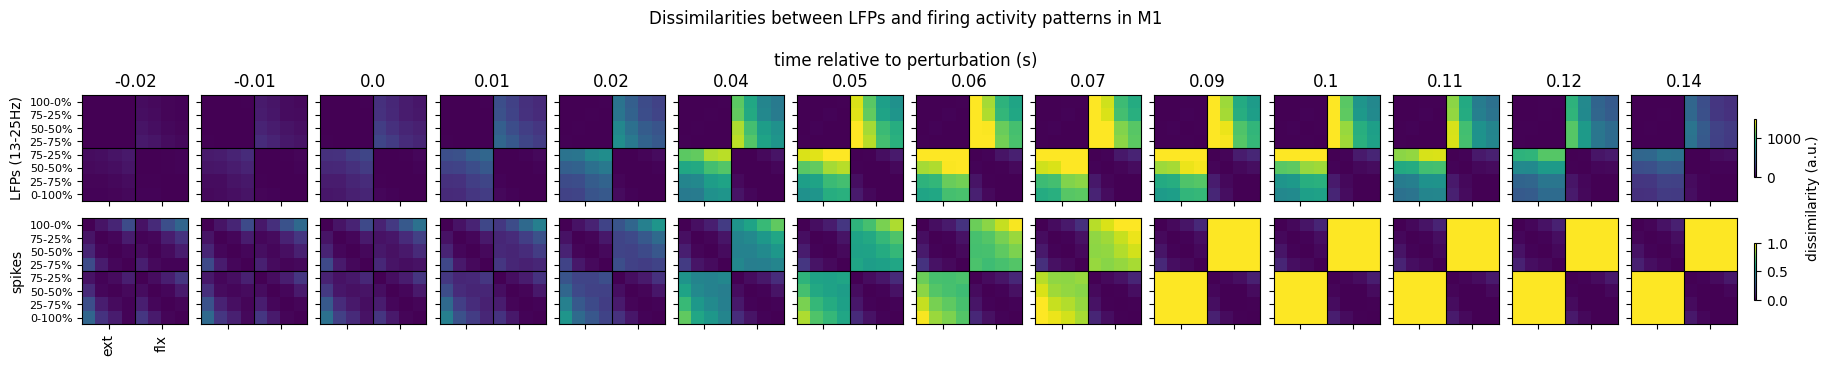

In [68]:
D_lfp, D_spk = [], []
roi = 'M1'
for mon in monkey:
    for rec in recordings[mon][roi]:
        G_lfp = np.load(os.path.join(baseDir, pcmDir, mon, f'G_obs.lfp.{roi}.exec-{rec}.npy'))
        freq = freq_masks['beta'] #+ freq_masks['gamma']
        G_lfp = G_lfp[freq].mean(axis=0)
        G_spk = np.load(os.path.join(baseDir, pcmDir, mon, f'G_obs.spk.{roi}.exec-{rec}.npy'))
        D_lfp.append(pcm.G_to_dist(G_lfp))
        D_spk.append(pcm.G_to_dist(G_spk))
D_lfp, D_spk = np.array(D_lfp).mean(axis=0), np.array(D_spk).mean(axis=0)
# D_lfp, D_spk = np.sign(D_lfp) * np.sqrt(np.abs(D_lfp)), np.sign(D_spk) * np.sqrt(np.abs(D_spk))
n_timep = 14
timep = np.linspace(-2, 14, n_timep, dtype=int)
fig, axs = plt.subplots(2, n_timep, figsize=(18, 3.5), sharex=True, sharey=True, constrained_layout=True)
for i in range(n_timep):
    ax = axs[:, i]
    ax[0].imshow(D_lfp[pertIdx+timep[i]], vmin=0, vmax=1500)
    ax[1].imshow(D_spk[pertIdx+timep[i]], vmin=0, vmax=1)
    ax[0].set_title(timep[i] / 100)
    ax[0].set_yticks(np.arange(0, 8))
    ax[0].set_xticks(np.arange(1.5, 9.5, 4))
    ax[1].tick_params(labelbottom=False, labelleft=False)
    ax[0].tick_params(labelleft=False)
    for j in range(2):
        ax[j].axhline(3.5, color='k', lw='.8')
        ax[j].axvline(3.5, color='k', lw='.8')

axs[0, 0].set_ylabel('LFPs (13-25Hz)')
axs[1, 0].set_ylabel('spikes')
axs[0, 0].tick_params(labelleft=True)
axs[0, 0].set_yticklabels(['100-0%', '75-25%', '50-50%', '25-75%', '75-25%', '50-50%', '25-75%', '0-100%'], fontsize=8)
axs[1, 0].set_yticklabels(['100-0%', '75-25%', '50-50%', '25-75%', '75-25%', '50-50%', '25-75%', '0-100%'], fontsize=8)
axs[1, 0].set_xticklabels(['ext', 'flx'], rotation=90)
axs[1, 0].tick_params(labelbottom=True, labelleft=True)
fig.suptitle(f'Dissimilarities between LFPs and firing activity patterns in {roi}\n\ntime relative to perturbation (s)')
cax = axs[0, -1].get_images()[0]
cbar = fig.colorbar(cax, ax=axs[0], orientation='vertical', fraction=.01, shrink=.5, pad=.01)
cax = axs[1, -1].get_images()[0]
cbar = fig.colorbar(cax, ax=axs[1], orientation='vertical', fraction=.01, shrink=.5, pad=.01)
fig.text(1, .45, 'dissimilarity (a.u.)', va='center', rotation='vertical', ha='left')

plt.show()

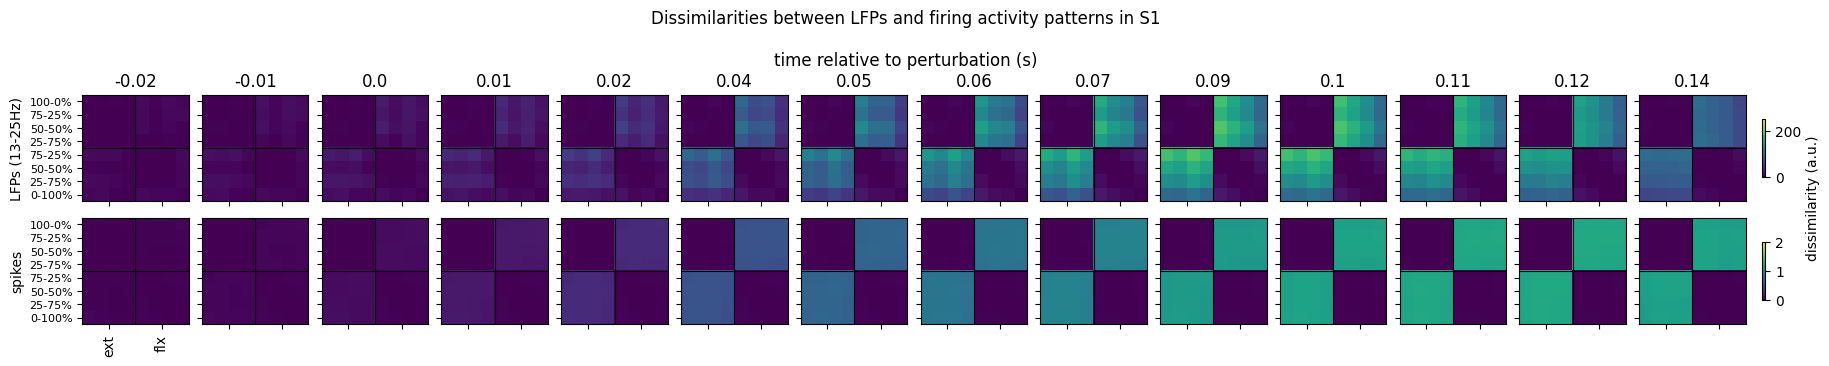

In [55]:
D_lfp, D_spk = [], []
roi = 'S1'
for mon in monkey:
    for rec in recordings[mon][roi]:
        G_lfp = np.load(os.path.join(baseDir, pcmDir, mon, f'G_obs.lfp.{roi}.exec-{rec}.npy'))
        freq = freq_masks['beta'] #+ freq_masks['gamma']
        G_lfp = G_lfp[freq].mean(axis=0)
        G_spk = np.load(os.path.join(baseDir, pcmDir, mon, f'G_obs.spk.{roi}.exec-{rec}.npy'))
        D_lfp.append(pcm.G_to_dist(G_lfp))
        D_spk.append(pcm.G_to_dist(G_spk))
D_lfp, D_spk = np.array(D_lfp).mean(axis=0), np.array(D_spk).mean(axis=0)
#D_lfp, D_spk = np.sign(D_lfp) * np.sqrt(np.abs(D_lfp)), np.sign(D_spk) * np.sqrt(np.abs(D_spk))
n_timep = 14
timep = np.linspace(-2, 14, n_timep, dtype=int)
fig, axs = plt.subplots(2, n_timep, figsize=(18, 3.5), sharex=True, sharey=True, constrained_layout=True)
for i in range(n_timep):
    ax = axs[:, i]
    ax[0].imshow(D_lfp[pertIdx+timep[i]], vmin=0, vmax=250)
    ax[1].imshow(D_spk[pertIdx+timep[i]], vmin=0, vmax=2)
    ax[0].set_title(timep[i] / 100)
    ax[0].set_yticks(np.arange(0, 8))
    ax[0].set_xticks(np.arange(1.5, 9.5, 4))
    ax[1].tick_params(labelbottom=False, labelleft=False)
    ax[0].tick_params(labelleft=False)
    for j in range(2):
        ax[j].axhline(3.5, color='k', lw='.8')
        ax[j].axvline(3.5, color='k', lw='.8')

axs[0, 0].set_ylabel('LFPs (13-25Hz)')
axs[1, 0].set_ylabel('spikes')
axs[0, 0].tick_params(labelleft=True)
axs[0, 0].set_yticklabels(['100-0%', '75-25%', '50-50%', '25-75%', '75-25%', '50-50%', '25-75%', '0-100%'], fontsize=8)
axs[1, 0].set_yticklabels(['100-0%', '75-25%', '50-50%', '25-75%', '75-25%', '50-50%', '25-75%', '0-100%'], fontsize=8)
axs[1, 0].set_xticklabels(['ext', 'flx'], rotation=90)
axs[1, 0].tick_params(labelbottom=True, labelleft=True)
fig.suptitle(f'Dissimilarities between LFPs and firing activity patterns in {roi}\n\ntime relative to perturbation (s)')
cax = axs[0, -1].get_images()[0]
cbar = fig.colorbar(cax, ax=axs[0], orientation='vertical', fraction=.01, shrink=.5, pad=.01)
cax = axs[1, -1].get_images()[0]
cbar = fig.colorbar(cax, ax=axs[1], orientation='vertical', fraction=.01, shrink=.5, pad=.01)
fig.text(1, .45, 'dissimilarity (a.u.)', va='center', rotation='vertical', ha='left')

plt.show()